Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


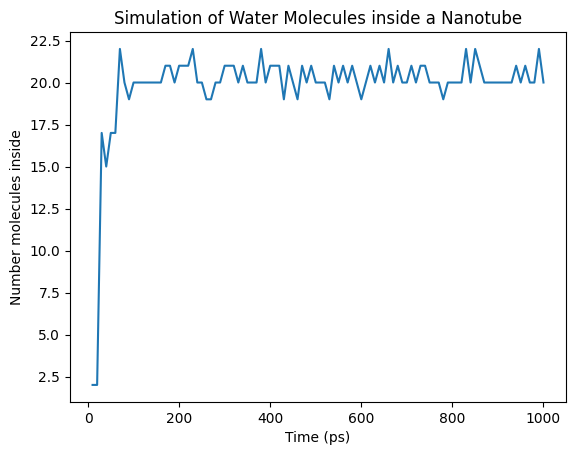

In [6]:
!pip install -q MDAnalysis
import MDAnalysis as mda
import matplotlib.pyplot as plt
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Definir rutas de archivos
path = '/content/drive/MyDrive/simulacions/04-05-26/equilibration/'
psf_file = path + 'system.psf'
dcd_file = path + 'MDequil.dcd'

# Load trajectory
simulacio = mda.Universe(psf_file, dcd_file)

# init list
time = []
waterin = []

# Loop over frames calculating water inside as a function of time
for ts in simulacio.trajectory:
    time.append(simulacio.trajectory.time)
    waterin.append(len(simulacio.select_atoms('type OT and prop abs z < 6.7')))

# Plot
plt.plot(time, waterin)
plt.xlabel('Time (ps)')
plt.ylabel('Number molecules inside')
plt.title('Simulation of Water Molecules inside a Nanotube')
plt.show()